
# Практическое задание №1

Проанализируйте данные о вакансиях на глобальном рынке труда в сфере ИИ в 2025 году.

[Источник](https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025)

В файле `ai_job_dataset.csv` содержаться следующие переменные:


- job_id: Unique identifier for each job posting
- job_title: Standardized job title
- salary_usd:	Annual salary in USD
- salary_currency:	Original salary currency
- salary_local:	Salary in local currency
- experience_level:	EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- employment_type:	FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance)
- company_location:	Country where company is located
- company_size:	S (Small <50), M (Medium 50-250), L (Large >250)
- employee_residence:	Country where employee resides
- remote_ratio:	0 (No remote), 50 (Hybrid), 100 (Fully remote)
- required_skills:	Top 5 required skills (comma-separated)
- education_required:	Minimum education requirement
- years_experience:	Required years of experience
- industry:	Industry sector of the company
- posting_date:	Date when job was posted
- application_deadline:	Application deadline
- job_description_length:	Character count of job description
- benefits_score:	Numerical score of benefits package (1-10)

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ai_job_dataset.csv") # Чтение файла

1. Опишите датасет (число наблюдений и переменных, пропущенных значений, типы данных, типы шкал переменных).

In [3]:
df.info() # Информация о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

Число наблюдений = 15000, число переменных = 19, пропущенных значений нет, т.к. все столбцы имеют по 15000 no-null значений, типы данных: float64 - 1 столбец (benefits_score)
int64 - 4 столбца (salary_usd, remote_ratio years_experience, job_description_length)
object - 13 столбцов (остальные).

In [4]:
# Определяем типы шкал переменных
for column in df.columns: # Проходимся циклом по столбцам
  print(f"{column} - {df[column].unique()}") # Выводи название столбца и его уникальные переменные

job_id - ['AI00001' 'AI00002' 'AI00003' ... 'AI14998' 'AI14999' 'AI15000']
job_title - ['AI Research Scientist' 'AI Software Engineer' 'AI Specialist'
 'NLP Engineer' 'AI Consultant' 'AI Architect' 'Principal Data Scientist'
 'Data Analyst' 'Autonomous Systems Engineer' 'AI Product Manager'
 'Machine Learning Engineer' 'Data Engineer' 'Research Scientist'
 'ML Ops Engineer' 'Robotics Engineer' 'Head of AI'
 'Deep Learning Engineer' 'Data Scientist' 'Machine Learning Researcher'
 'Computer Vision Engineer']
salary_usd - [ 90376  61895 152626 ... 189490  79461  56481]
salary_currency - ['USD' 'EUR' 'GBP']
experience_level - ['SE' 'EN' 'MI' 'EX']
employment_type - ['CT' 'FL' 'PT' 'FT']
company_location - ['China' 'Canada' 'Switzerland' 'India' 'France' 'Germany'
 'United Kingdom' 'Singapore' 'Austria' 'Sweden' 'South Korea' 'Norway'
 'Netherlands' 'United States' 'Israel' 'Australia' 'Ireland' 'Denmark'
 'Finland' 'Japan']
company_size - ['M' 'L' 'S']
employee_residence - ['China' 'Irelan

Мы выидим, что у некоторых столбцов есть "особые" типы переменных, например salary_currency имеет всего 3 значения USD, EUR, GBP, а experience_level - 4: SE, EN, MI, EX.

2. Отобразите первые пять строк и последние три строки датасета.

In [5]:
df[:5]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [6]:
df[-3:]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


3. Установите идентификатор вакансии (job_id) как индекс строк.

In [7]:
df = pd.read_csv("ai_job_dataset.csv", index_col=0)

4. Выведите список названий столбцов таблицы.

In [8]:
df.columns

Index(['job_title', 'salary_usd', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

5. Выведите информацию о проценте непустых ячеек в каждом столбце.

In [9]:
# Из предыдущего пункта 1 мы знаем что всего строк 15000
for column in df.columns:
    print(f"{column} - {df[column].count() / 15000 * 100}%") # Вывод процента непустых ячеек в каждом столбце


job_title - 100.0%
salary_usd - 100.0%
salary_currency - 100.0%
experience_level - 100.0%
employment_type - 100.0%
company_location - 100.0%
company_size - 100.0%
employee_residence - 100.0%
remote_ratio - 100.0%
required_skills - 100.0%
education_required - 100.0%
years_experience - 100.0%
industry - 100.0%
posting_date - 100.0%
application_deadline - 100.0%
job_description_length - 100.0%
benefits_score - 100.0%
company_name - 100.0%


6. Выведите описательные статистики по столбцам, содержащим количественные данные.

In [10]:
# Выборка столбцов, содержащих количественные данные: в данном случае это int64, float64 (п1)
df.select_dtypes(include=['int64', 'float64']).describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


7. Переименуйте столбец "industry" в "industry_comp".

In [11]:
df = df.rename(columns={'industry': 'industry_comp'})

8. Выведите столбцы, характеризующие вознаграждение за работу.

In [12]:
df[['salary_usd', 'benefits_score']] # Вывод столбцов с информацией о зарпалате и об оценке пакета льгот

,salary_usd,benefits_score
job_id,,
AI00001,90376,5.9
AI00002,61895,5.2
AI00003,152626,9.4
AI00004,80215,8.6
AI00005,54624,6.6
...,...,...
AI14996,38604,7.9
AI14997,57811,8.2
AI14998,189490,7.4


9. Выведите название позиции для вакансии с идентификатором AI00056.

In [13]:
df.at['AI00056', 'job_title']

'AI Architect'

10. Отобразите данные о вакансиях, в которых заработная плата выше 200000 долларов США.

In [14]:
df[df['salary_usd'] > 200000].describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,1483.000000,1483.000000,1483.000000,1483.000000,1483.000000
mean,249332.607552,50.134862,13.868510,1486.911666,7.562846
std,40931.218346,40.658987,3.415389,578.025356,1.486440
min,200027.000000,0.000000,5.000000,500.000000,5.000000
25%,216240.000000,0.000000,11.000000,969.000000,6.200000
50%,238538.000000,50.000000,14.000000,1491.000000,7.600000
75%,273026.500000,100.000000,17.000000,1978.000000,8.900000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


11. Создайте новый столбец, в котором размер заработной платы рассчитан в рублях по текущему курсу.

In [15]:
USD_to_RUB = 82.87 # Текущий курс
df['salary_rub'] = df['salary_usd'] * USD_to_RUB # Создание столбца

12. Создайте новый столбец is_local, который будет иметь значение True, если company_location == employee_residence, и False в противном случае.

In [16]:
df['is_local'] = df['company_location'] == df['employee_residence']

13. Рассчитайте средние заработные платы для вакансий с различными требованиями к опыту кандидатов.

In [17]:
df.groupby('experience_level')['salary_usd'].mean()

,salary_usd
experience_level,
EN,63133.377084
EX,187723.647340
MI,87955.471833
SE,122187.657845


Наблюдается последовательное увеличение заработной платы с ростом уровня опыта.

14. Рассчитайте минимальные заработные платы для различных должностей для компаний разного размера (в одной таблице).

In [18]:
df.groupby(['job_title', 'company_size'])['salary_usd'].min().unstack()

company_size,L,M,S
job_title,,,
AI Architect,41846,36338,33220
AI Consultant,42570,36071,33959
AI Product Manager,42239,36162,33770
AI Research Scientist,42869,36574,33092
AI Software Engineer,42835,36152,33013
AI Specialist,41740,36553,34174
Autonomous Systems Engineer,42185,36197,32790
Computer Vision Engineer,42189,36732,32519
Data Analyst,41634,36523,32542


15. Рассчитайте медиану требуемого опыта работы в годах для вакансий в китайских компаниях с требованием уровня образования не ниже магистерского.

In [19]:
# Создаем новую таблицу, в которой только китайские компании с требованием уровня образования не ниже магистерского
df1 = df[(df['company_location'] == 'China') & (df['education_required'].isin(['Master', 'PhD']))]
df1['years_experience'].median() # Расчитываем медиану

5.0

16. Постройте гистограммы трех различных метрических переменных и опишите их. Столбики первой гистограммы должны быть красного цвета, второй - синего, третьей - зеленого.

<Axes: >

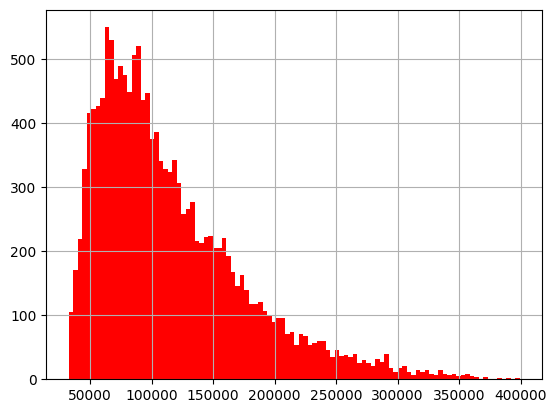

In [20]:
df.salary_usd.hist(bins=100, color='red')

Гистограмма демонстрирует распределение заработных плат в долларах США с использованием 100 интервалов группировки.

<Axes: >

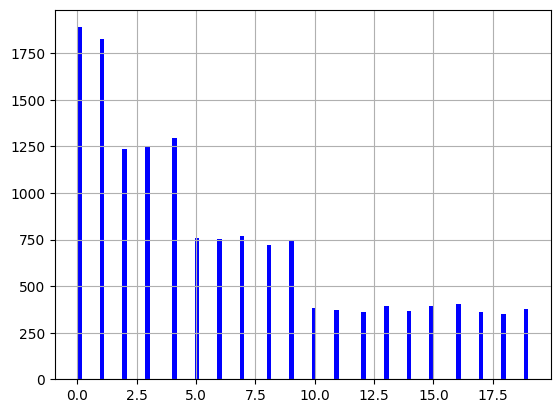

In [21]:
df.years_experience.hist(bins=100, color='blue')

Гистограмма показывает распределение требований к опыту работы кандидатов с использованием 100 интервалов.

<Axes: >

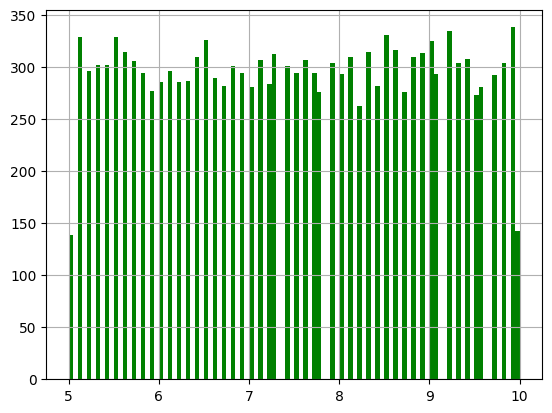

In [22]:
df.benefits_score.hist(bins=100, color='green')

Гистограмма демонстрирует распределение оценок пакетов дополнительных льгот с использованием 100 интервалов.

17. Постройте диаграмму, демонстрирующую взаимосвязь между размером компании и заработной платой. Добавьте название диаграмме и подписи осям. Обоснуйте выбор диаграммы и прокомментируйте тенденции и взаимосвязи, которые на ней отображены.

<Axes: title={'center': 'Средние зарплаты по размерам компаний'}, xlabel='company_size', ylabel='salary_usd'>

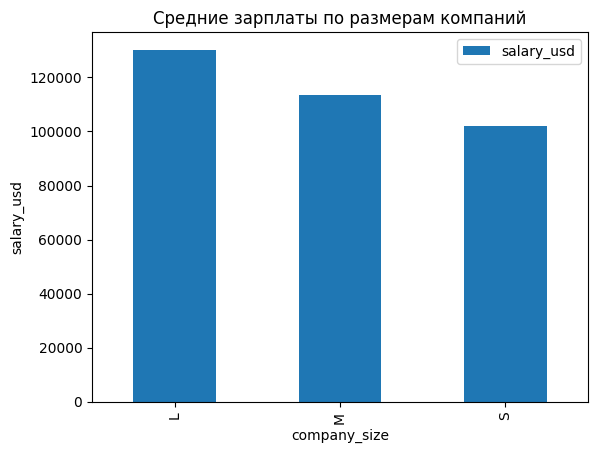

In [23]:
# Создание сводной таблицы со средними зарплатами по размерам компаний и визуализация результатов в виде столбчатой диаграммы
df.pivot_table(values='salary_usd', index='company_size', aggfunc='mean').plot(kind='bar', title='Средние зарплаты по размерам компаний', xlabel='company_size', ylabel='salary_usd')


Я выбрала столбчатую диаграмму, так как столбец company_size имеет категориальные переменные. По диаграмме видно, что зарплаты увеличиваются с ростом размера компании.

18. Постройте ящичковую диаграмму заработной платы. Наблюдаются ли выбросы?

<Axes: >

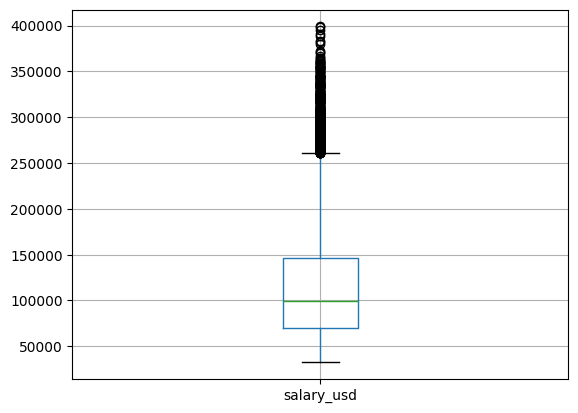

In [24]:
df.boxplot(column='salary_usd')

Наблюдаются выбросы.

19. Определите топ-5 стран по количеству вакансий. Визуализируйте это с помощью столбчатой диаграммы.

<Axes: xlabel='company_location'>

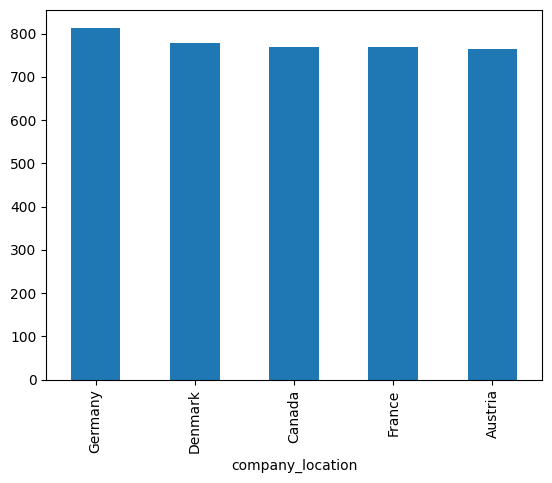

In [25]:
# Группировка данных по странам расположения компаний, подсчет количества вакансий в каждой стране (.count()),
# сортировка по убыванию, выбор первых 5 и визуализация результатов в виде столбчатой диаграммы
df.groupby(['company_location'])['job_description_length'].count().sort_values(ascending=False).head(5).plot(kind='bar')

Топ 5 стран: Германия, Денмарк, Канада, Франция, Австралия.

20. Как связаны формат работы и зарплата? Кто получает больше — офисные, гибридные или полностью удалённые работники? Отличаются ли эти тенденции по странам?

In [26]:
# Группировка данных по проценту удаленной работы и расчет средних значений зарплат для каждой категории
df.groupby(['remote_ratio'])['salary_usd'].mean()

,salary_usd
remote_ratio,
0,114140.231133
50,115776.806793
100,116160.545935


Уровень зарплаты растет со степенью удаленности работы. Полностью удаленные сотрудники получают в среднем более высокие зарплатные предложения по сравнению с сотрудниками, работающими в офисе или по гибридной модели.


In [27]:
# Группировка данных одновременно по странам и форматам работы с расчетом средних зарплат
df.pivot_table(
    values='salary_usd',
    index='company_location',
    columns='remote_ratio',
    aggfunc='mean'
)

remote_ratio,0,50,100
company_location,,,
Australia,112571.071429,125773.799180,116280.576000
Austria,85603.047431,83156.739837,86633.033835
Canada,114423.847656,112386.790698,115970.584314
China,83476.193916,83823.410480,87188.708487
Denmark,163423.709804,171369.384906,161982.624031
Finland,86555.639405,87943.762295,92248.140909
France,114823.125000,113967.293893,114454.924303
Germany,116345.082143,118972.318339,131403.404082
India,85513.438525,82783.168675,84427.950192


Тенденции по странам отличаются, например, в Австрилии больше всего получают работники гибридного формата, а в Нидерландах - офисные работники.

21. Насколько часто место расположения компании и место проживания сотрудника не совпадают? Влияет ли это на зарплату?

In [28]:
# Создаем таблицу df2 с дополнительным столбцом: True - если расположения совпадают, иначе - False
df2 = df
df2['coincidence_locations'] = df['company_location'] == df['employee_residence']
df2['coincidence_locations'].value_counts(normalize=True) # Подсчитываем частоту значений в столбце

,proportion
coincidence_locations,
True,0.716267
False,0.283733


Место расположения компании и место проживания сотрудника не совпадает в 28.4% случаев.

In [29]:
# Определяем среднее занчение зарплат в зависимости от совпадения локации работы и место жительства
df2.groupby(['coincidence_locations'])['salary_usd'].mean()

,salary_usd
coincidence_locations,
False,116282.396617
True,114979.206720


Данные показывают, что расположение компании и место проживания сотрудника влияют на зарплату, зарплата больше, когда локации совпадают.

22. Охарактеризуйте распределение требуемого опыта работы для каждой профессии.

In [30]:
df.groupby('job_title')['years_experience'].describe()

,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
AI Architect,771.0,6.498054,5.422027,0.0,2.0,5.0,10.0,19.0
AI Consultant,704.0,6.099432,5.406260,0.0,2.0,4.0,9.0,19.0
AI Product Manager,743.0,6.086137,5.462256,0.0,1.0,4.0,9.5,19.0
AI Research Scientist,756.0,6.403439,5.689534,0.0,2.0,5.0,10.0,19.0
AI Software Engineer,784.0,6.227041,5.724584,0.0,1.0,4.0,10.0,19.0
AI Specialist,728.0,6.561813,5.588505,0.0,2.0,5.0,10.0,19.0
Autonomous Systems Engineer,777.0,6.088803,5.456113,0.0,2.0,4.0,9.0,19.0
Computer Vision Engineer,724.0,5.954420,5.325569,0.0,2.0,4.0,9.0,19.0
Data Analyst,759.0,5.956522,5.404919,0.0,1.0,4.0,9.0,19.0


Анализ показывает средний требуемый опыт варьируется в диапазоне 5.9-6.7 лет. Универсальный диапазон 0-19 лет.

ВЫСОКИЙ УРОВЕНЬ (6.4+ лет)
- Machine Learning Engineer (6.7)
- AI Specialist (6.6)
- Head of AI (6.5)
- AI Architect (6.5)
- Robotics Engineer (6.5)

СРЕДНИЙ УРОВЕНЬ (6.0-6.4 лет)
- AI Research Scientist (6.4)
- Data Scientist (6.3)
- ML Ops Engineer (6.3)
- Data Engineer (6.3)
- Research Scientist (6.3)

НИЗКИЙ УРОВЕНЬ (5.9-6.0 лет)
- AI Software Engineer (6.2)
- AI Consultant (6.1)
- Principal Data Scientist (6.1)
- AI Product Manager (6.1)
- Autonomous Systems Engineer (6.1)
- Deep Learning Engineer (6.1)
- Machine Learning Researcher (6.1)
- Computer Vision Engineer (5.9)
- NLP Engineer (5.9)
- Data Analyst (5.9)

23. Есть ли взаимосвязь между числом символов в описании вакансии и зарплатой?

In [31]:
df['job_description_length'].corr(df['salary_usd']) # Корреляционный анализ

np.float64(-0.009092217059826402)

Корреляция почти нулевая, значит взаимосвязь между числом символов в описании и зарплатой отсутсвует.

24. Визуализируйте распределение вакансий по месяцам (posting_date). Какие тенденции наблюдаются?

<Axes: xlabel='posting_month'>

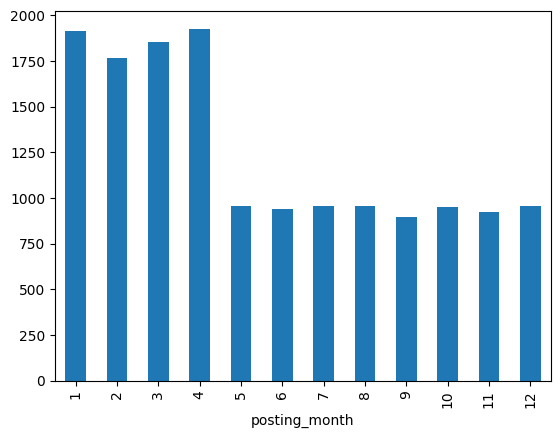

In [32]:
df3 = df
# Преобразуем даты в datetime и извлекаем месяц
df3['posting_date'] = pd.to_datetime(df3['posting_date'])
df3['posting_month'] = df3['posting_date'].dt.month # Создаем отдельный столбец с месяцами
df3['posting_month'].value_counts().sort_index().plot(kind='bar') # Строим график

Больши всего вакансий приходится на начало года (особенно Январь, Апрель), меньше всего вакансий в летний и осений период.

25. Рассчитайте временную разницу между posting_date и application_deadline. Влияет ли она на зарплату?

<Axes: xlabel='application_period_days'>

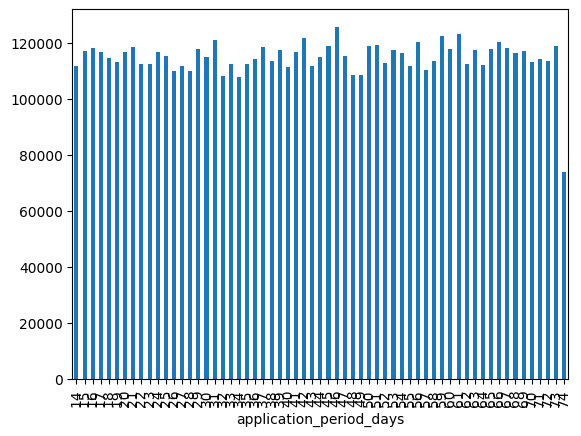

In [33]:
# Преобразование в datetime
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])
# Создание столбца с разницей в датах (в днях)
df['application_period_days'] = (df['application_deadline'] - df['posting_date']).dt.days
df.groupby('application_period_days')['salary_usd'].mean().plot(kind='bar')

По диаграмме видно, что разница между posting_date и application_deadline не влияет на зарплату.

26. Как сочетаются education_required и years_experience? Требуется ли больше лет опыта при меньшем образовании?

In [34]:
df.groupby('education_required')['years_experience'].describe()

,count,mean,std,min,25%,50%,75%,max
education_required,,,,,,,,
Associate,3785.0,6.205548,5.516650,0.0,2.0,4.0,10.0,19.0
Bachelor,3789.0,6.304038,5.619813,0.0,2.0,5.0,10.0,19.0
Master,3748.0,6.445037,5.609613,0.0,2.0,5.0,10.0,19.0
PhD,3678.0,6.054377,5.427023,0.0,1.0,4.0,9.0,19.0


Нет четкой обратной зависимости между уровнем образования и требуемым опытом. Наблюдается небольшой рост требуемого опыта от Associate к Master, но PhD требует меньше опыта, чем Master.

27. Опишите профиль вакансий с самыми высокими заработными платами (самостоятельно установите критерии отнесения зарплат к высоким). Что наиболее востребовано на таких вакансиях? Отличаются ли требования к кандидатам с самыми высокими зарплатами по странам?

In [35]:
high_salary = df['salary_usd'].quantile(0.85) # Критерий высоких зарплат: верхние 15% по зарплате
# Создаем таблицу, отбираем профессии с самыми высокими зарплатами
df4 = df[df['salary_usd'] > high_salary].sort_values('salary_usd', ascending=False)
df4.head() # Выводим топ 5

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,...,posting_date,application_deadline,job_description_length,benefits_score,company_name,salary_rub,is_local,coincidence_locations,posting_month,application_period_days
job_id,,,,,,,,,,,,,,,,,,,,,
AI09892,Machine Learning Researcher,399095,USD,EX,PT,Switzerland,L,Switzerland,0,"Linux, Python, TensorFlow",...,2024-07-10,2024-09-02,2277,9.7,TechCorp Inc,33073002.65,True,True,7,54
AI02310,AI Architect,398084,USD,EX,CT,Switzerland,L,Switzerland,100,"Python, Linux, Tableau, TensorFlow",...,2024-12-30,2025-02-20,1979,10.0,Future Systems,32989221.08,True,True,12,52
AI12500,AI Research Scientist,394917,USD,EX,CT,Switzerland,L,Switzerland,50,"Scala, PyTorch, Spark, Docker, Git",...,2024-06-04,2024-08-13,1310,6.6,Machine Intelligence Group,32726771.79,True,True,6,70
AI12804,AI Specialist,390292,USD,EX,FT,Switzerland,L,Switzerland,50,"Java, SQL, PyTorch, Statistics, TensorFlow",...,2024-12-27,2025-01-24,1900,7.5,DataVision Ltd,32343498.04,True,True,12,28
AI00318,Data Scientist,388754,USD,EX,CT,Switzerland,L,United States,0,"Docker, Python, Mathematics",...,2024-06-20,2024-08-11,829,8.6,DeepTech Ventures,32216043.98,False,False,6,52


Топ 5 высокооплачиваемых профессий: Machine Learning Researcher, AI Architect, AI Research Scientist, AI Specialist, Data Scientist.

In [36]:
df4['required_skills'].value_counts()

,count
required_skills,
"Python, TensorFlow, SQL",3
"Python, TensorFlow, Deep Learning",2
"Java, SQL, Linux",2
"Python, Git, TensorFlow",2
"Scala, Kubernetes, MLOps",2
...,...
"R, SQL, Java, AWS",1
"PyTorch, Python, AWS",1
"SQL, Hadoop, Data Visualization, Deep Learning",1


Наиболее востребовано на высокоплачиваемых вакансиях знание Python, TensorFlow, SQL.

In [37]:
df4.groupby('company_location')['required_skills'].describe()

,count,unique,top,freq
company_location,,,,
Australia,122,122,"Kubernetes, Scala, Java, Docker, Azure",1
Austria,25,25,"Deep Learning, Hadoop, SQL, TensorFlow, Mathem...",1
Canada,104,104,"PyTorch, Tableau, Azure, NLP",1
China,24,24,"Deep Learning, PyTorch, Azure, Scala",1
Denmark,294,293,"SQL, Deep Learning, Python",2
Finland,22,22,"Deep Learning, AWS, Linux, Statistics, SQL",1
France,103,103,"PyTorch, R, Python, Scala",1
Germany,134,134,"Kubernetes, PyTorch, Java, Git, Computer Vision",1
India,19,19,"GCP, Tableau, PyTorch, Statistics",1


Да, по странам тербования к кандидатам отличаются.

**Комментарии к заданию и принципам его оценивания:**

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов описательного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 30 сентября.

- При сдаче работы до 23:55 1 октября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 2 октября вычитаются 2 балла из итоговой оценки.
- После **23:55 2 октября** работа не принимается.